In [1]:
from pathlib import Path
import os
import sys
import pandas as pd
import numpy as np
import pickle

In [3]:
sys.path.append('C:/Users/marielmoran/Desktop/MiM/notebooks/tools')

In [12]:
from some_tools import *

## Estructura de Carpetas

In [4]:
DIR = sys.path.append('C:/Users/marielmoran/Desktop/MiM/data')
BASE = Path('C:/Users/marielmoran/Desktop/MiM/data')

In [6]:
datasets = os.listdir(BASE/'raw-data/')

In [10]:
# Estructura de carpetas a crear
folders = {str(BASE.as_posix()):
            {'/images':dict.fromkeys(['/'+dataset for dataset in datasets])
            ,'/labels': None
            ,'/splits':None}
        }

In [13]:
# Crea la estructura de carpetas si aún no estan creadas.
create_folders_scheme(folders)

Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/images/DDR-dataset".
Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/images/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-".
Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/images/HRF - Quality".
Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/images/Kaggle".
Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/images/RETINOGRAFIAS - Calidad".
Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/labels".
Created successfully: "C:/Users/marielmoran/Desktop/MiM/data/splits".


## Archivo Label
Se crea un archivo pickle para cada dataset, donde se guardará el nombre de archivo y la etiqueta. 

### HRF

In [14]:
raw_HRF = Path(BASE/'raw-data/HRF - Quality')

In [15]:
labels_HRF = pd.DataFrame()
labels_HRF['filename'] = [name for name in os.listdir(raw_HRF) if not name.startswith('._')]
labels_HRF['file_path'] = labels_HRF.filename.apply(lambda x: raw_HRF/x)
labels_HRF['label'] = labels_HRF.filename.apply(lambda x: int('bad' in x)) 

In [20]:
labels_HRF.to_pickle(BASE/'labels/HRF.pkl')

### DDR

In [21]:
raw_DDR = Path(BASE/'raw-data/DDR-dataset/DR_grading')

In [22]:
labels_DDR_train = pd.read_csv(raw_DDR/'train.txt',sep=' ', header = None)
labels_DDR_train.columns = ['filename','label']
labels_DDR_train['file_path'] = labels_DDR_train.filename.apply(lambda x: raw_DDR/'train'/x)

labels_DDR_val = pd.read_csv(raw_DDR/'valid.txt',sep=' ', header = None)
labels_DDR_val.columns = ['filename','label']
labels_DDR_val['file_path'] = labels_DDR_val.filename.apply(lambda x: raw_DDR/'valid'/x)


labels_DDR_test = pd.read_csv(raw_DDR/'test.txt',sep=' ', header = None)
labels_DDR_test.columns = ['filename','label']
labels_DDR_test['file_path'] = labels_DDR_test.filename.apply(lambda x: raw_DDR/'test'/x)


labels_DDR = pd.concat([labels_DDR_train, labels_DDR_val, labels_DDR_test],ignore_index=True)

In [23]:
labels_DDR = labels_DDR.reindex(columns=['filename','file_path','label'])

In [25]:
labels_DDR.to_pickle(BASE/'labels/DDR.pkl')

### Retinografía

In [26]:
raw_Retinografia = Path(BASE/'raw-data/RETINOGRAFIAS - Calidad')

In [27]:
labels_Retin_Buena = pd.DataFrame()
labels_Retin_Buena['filename'] = [name for name in os.listdir(raw_Retinografia/'Buena Calidad') if not name.startswith('._')] 
labels_Retin_Buena['file_path'] = labels_Retin_Buena.filename.apply(lambda x: raw_Retinografia/'Buena Calidad'/x)
labels_Retin_Buena['label'] = 0

In [28]:
Retin_Mala_filename = []
for i in os.listdir(raw_Retinografia/'Mala Calidad'):
    for j in os.listdir(raw_Retinografia/'Mala Calidad'/i):
        filename = j
        file_path = raw_Retinografia/'Mala Calidad'/i/j
        Retin_Mala_filename.append((filename,file_path))

In [29]:
labels_Retin_Mala = pd.DataFrame(Retin_Mala_filename, columns = ['filename','file_path'])
labels_Retin_Mala['label'] = 1

In [30]:
Retin_Regular_filename = []
for i in os.listdir(raw_Retinografia/'Regular Calidad'):
    for j in os.listdir(raw_Retinografia/'Regular Calidad'/i):
        filename = j
        file_path = raw_Retinografia/'Regular Calidad'/i/j
        Retin_Regular_filename.append((filename,file_path))

In [31]:
labels_Retin_Regular = pd.DataFrame(Retin_Regular_filename, columns = ['filename','file_path'])
labels_Retin_Regular['label'] = 1

In [32]:
labels_Retinografia = pd.concat([labels_Retin_Buena, labels_Retin_Mala, labels_Retin_Regular],ignore_index=True)

In [33]:
labels_Retinografia.to_pickle(BASE/'labels/Retinografia.pkl')

### Kaggle

In [34]:
raw_kaggle = Path(BASE/'raw-data/Kaggle')

In [35]:
# MARCA ZHOU
with open(raw_kaggle/'labels_quality_assessment_zhou2018.pkl','rb') as f:
    zhou = pickle.load(f)

In [36]:
# MARCA FU
with open(raw_kaggle/'labels_quality_assessment_fu2019.pkl','rb') as f:
    fu = pickle.load(f)

In [37]:
labels_kaggle_zhou = pd.DataFrame(list(zhou.items()), columns = ['filename','label'])
#labels_kaggle_zhou = labels_kaggle_zhou[labels_kaggle_zhou.filename.isin(['1188_right','1188_left'])]
labels_kaggle_zhou['filename'] = labels_kaggle_zhou.filename + '.png'
labels_kaggle_zhou['file_path'] = labels_kaggle_zhou.filename.apply(lambda x: raw_kaggle/'images'/x)
labels_kaggle_zhou = labels_kaggle_zhou.reindex(columns=['filename','file_path','label'])

In [38]:
labels_kaggle_fu = pd.DataFrame(list(fu.items()),columns = ['filename','label'])
#labels_kaggle_fu = labels_kaggle_fu[labels_kaggle_fu.filename.isin(['1188_right','1188_left'])]
labels_kaggle_fu['filename'] = labels_kaggle_fu.filename + '.png'
labels_kaggle_fu['file_path'] = labels_kaggle_fu.filename.apply(lambda x: raw_kaggle/'images'/x)
labels_kaggle_fu = labels_kaggle_fu.reindex(columns=['filename','file_path','label'])

In [39]:
labels_kaggle_zhou.to_pickle(BASE/'labels/Kaggle_zhou.pkl')

In [40]:
labels_kaggle_fu.to_pickle(BASE/'labels/Kaggle_fu.pkl')

### Deep Diabetic Retinopathy Image Dataset DeepDRiD

In [41]:
raw_DRiD = Path(BASE/'raw-data/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-')

In [42]:
x = pd.read_csv(raw_DRiD/'regular_fundus_images/regular-fundus-training/regular-fundus-training.csv')
labels_DRiD_regular_train = x.loc[:,['image_path','Overall quality']]
labels_DRiD_regular_train['filename'] = labels_DRiD_regular_train.image_path.apply(lambda x: x.split('\\')[-1])
labels_DRiD_regular_train = labels_DRiD_regular_train.reindex(columns=['filename','image_path','Overall quality'])
labels_DRiD_regular_train.columns = ['filename','file_path','label']
labels_DRiD_regular_train['file_path'] = labels_DRiD_regular_train.filename.apply(lambda x: raw_DRiD/'regular_fundus_images/regular-fundus-training/Images'/x.split('_')[0]/x)
labels_DRiD_regular_train['label']=labels_DRiD_regular_train.label+1
labels_DRiD_regular_train.loc[labels_DRiD_regular_train.label == 2,'label']=0

In [43]:
x = pd.read_csv(raw_DRiD/'regular_fundus_images/regular-fundus-validation/regular-fundus-validation.csv')
labels_DRiD_regular_val = x.loc[:,['image_path','Overall quality']]
labels_DRiD_regular_val['filename'] = labels_DRiD_regular_val.image_path.apply(lambda x: x.split('\\')[-1])
labels_DRiD_regular_val = labels_DRiD_regular_val.reindex(columns=['filename','image_path','Overall quality'])
labels_DRiD_regular_val.columns = ['filename','file_path','label']
labels_DRiD_regular_val['file_path'] = labels_DRiD_regular_val.filename.apply(lambda x: raw_DRiD/'regular_fundus_images/regular-fundus-validation/Images'/x.split('_')[0]/x)
labels_DRiD_regular_val['label']=labels_DRiD_regular_val.label+1
labels_DRiD_regular_val.loc[labels_DRiD_regular_val.label == 2,'label']=0

In [44]:
labels_DRiD = pd.concat([labels_DRiD_regular_train,labels_DRiD_regular_val],ignore_index=True)

In [45]:
labels_DRiD.to_pickle(BASE/'labels/DRiD.pkl')

## Field of view (FOV)

Calcula el FOV y recorta la imagen a su alrededor.

In [6]:
pip install --upgrade Pillow

Requirement already up-to-date: Pillow in c:\users\marielmoran\anaconda3\lib\site-packages (9.0.1)


In [46]:
pip install pillow

Note: you may need to restart the kernel to use updated packages.


In [49]:
from PIL import Image # si uso esta lib la funcion crop no sirve porque para el return tendría que ponerle crop.
                        # si uso imageio parece tardar mucho mas
import imageio as io
import numpy as np
import matplotlib.pyplot as plt

### HRF

In [47]:
with open(BASE/'labels/HRF.pkl','rb') as f:
    HRF = pickle.load(f)

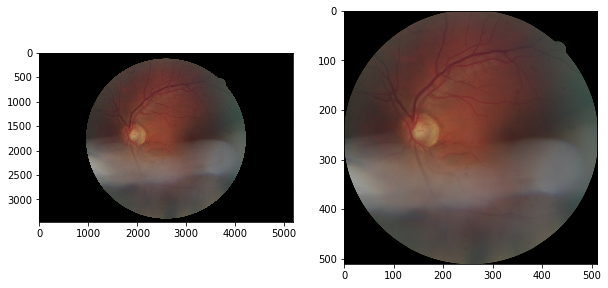

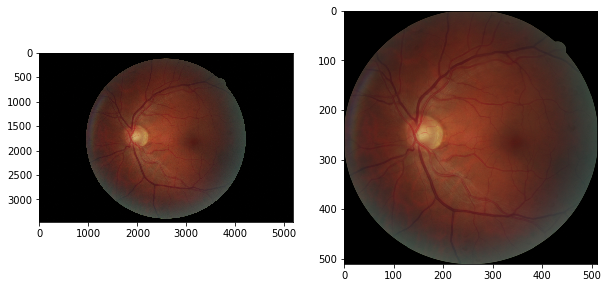

In [50]:
# con PILLOW
for image_dir in HRF.file_path:
    new_name = os.path.split(image_dir.with_suffix('.png'))[-1]
    im = Image.open(image_dir)
    im_fov = crop_fov_pill(im)
    im_fov = downsize_image(im_fov)

    im_fov.save(BASE/'images/HRF - Quality'/new_name)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov,cmap=plt.cm.gray) 
    plt.show()

### DDR

In [51]:
with open(BASE/'labels/DDR.pkl','rb') as f:
    DDR = pickle.load(f)

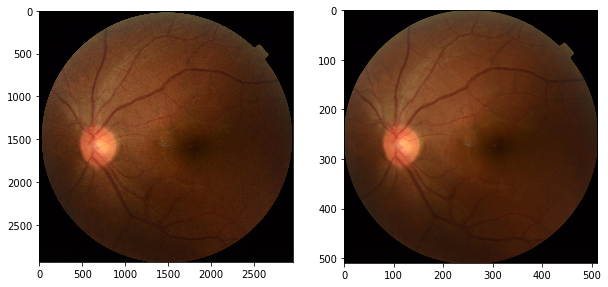

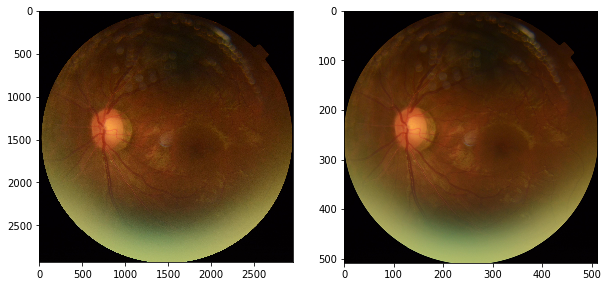

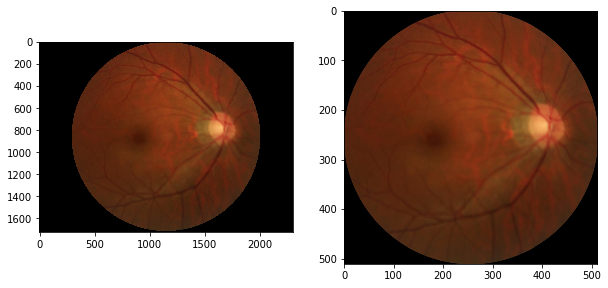

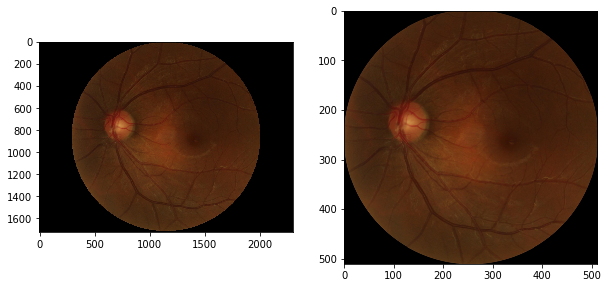

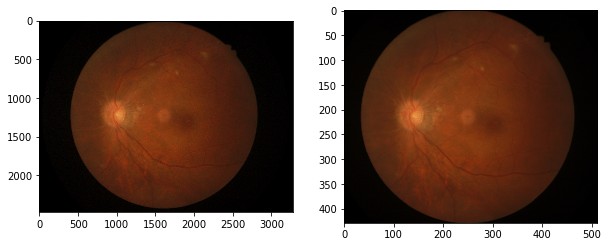

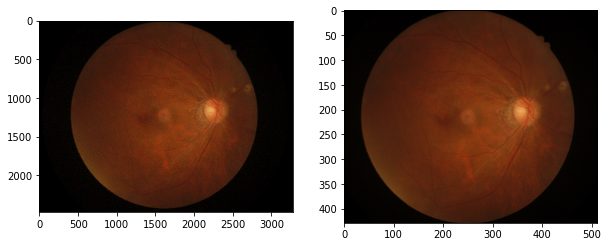

In [61]:
# con PILLOW
for image_dir in DDR.file_path:
    new_name = os.path.split(image_dir.with_suffix('.png'))[-1]
    im = Image.open(image_dir)
    im_fov = crop_fov_pill(im)
    im_fov = downsize_image(im_fov)
    im_fov.save(BASE/'images/DDR-dataset'/new_name)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov,cmap=plt.cm.gray) 
    plt.show()

### Retinografía

In [53]:
with open(BASE/'labels/Retinografia.pkl','rb') as f:
    retinografia = pickle.load(f)

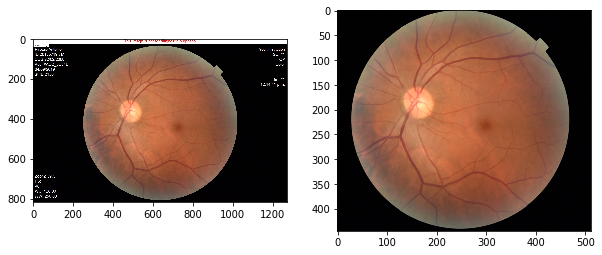

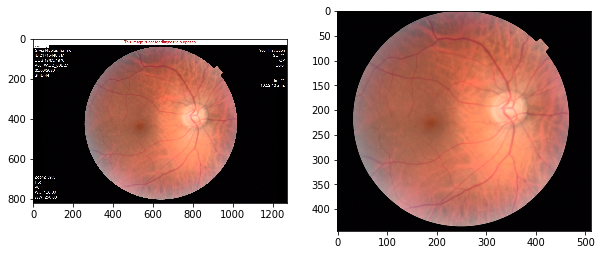

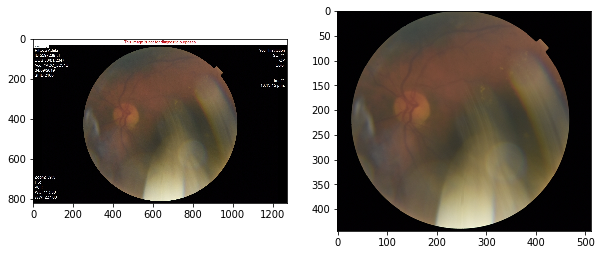

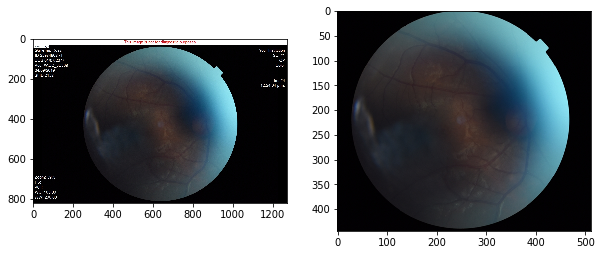

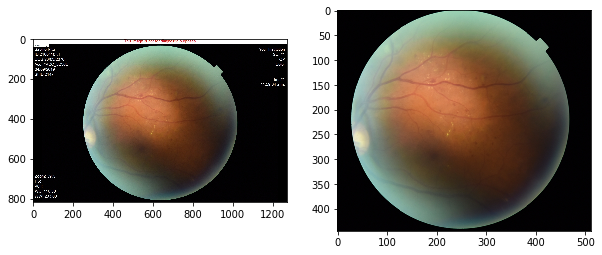

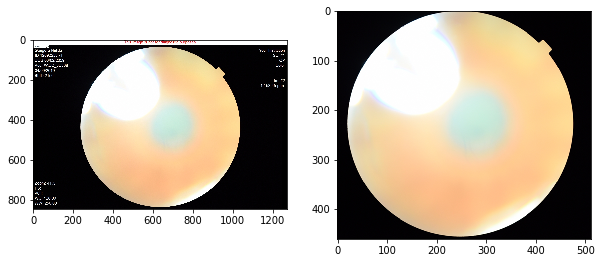

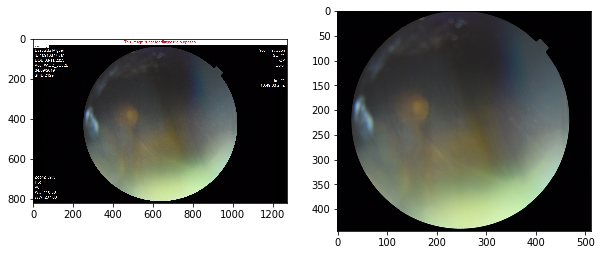

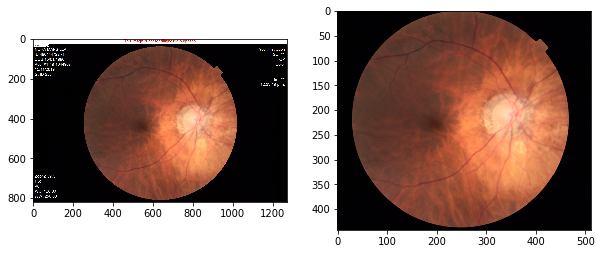

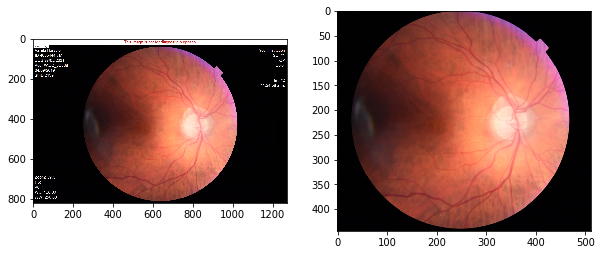

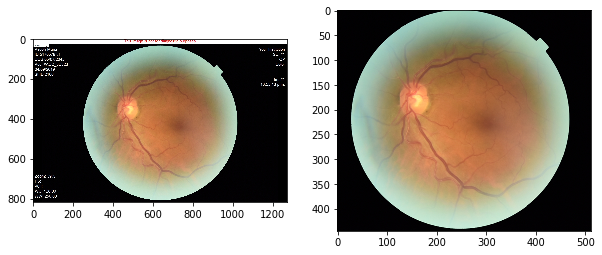

In [60]:
left = 200
right = 1100
top = 30

# con PILLOW
for image_dir in retinografia.file_path:
    new_name = os.path.split(image_dir.with_suffix('.png'))[-1]
    im = Image.open(image_dir)
    
    bottom = im.getbbox()[3]
    im_cropped = im.crop((left,top,right,bottom)) # recorta la parte de la imagen con inscripciones.

    im_fov = crop_fov_pill(im_cropped)
    im_fov = downsize_image(im_fov)

    im_fov.save(BASE/'images/RETINOGRAFIAS - Calidad'/new_name)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov,cmap=plt.cm.gray) 
    plt.show()

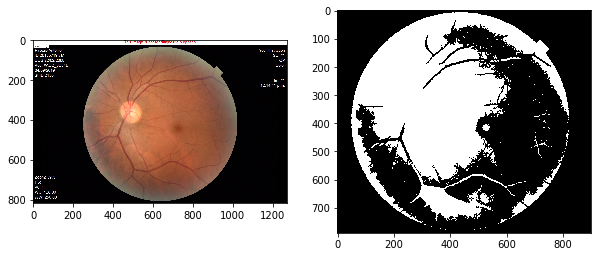

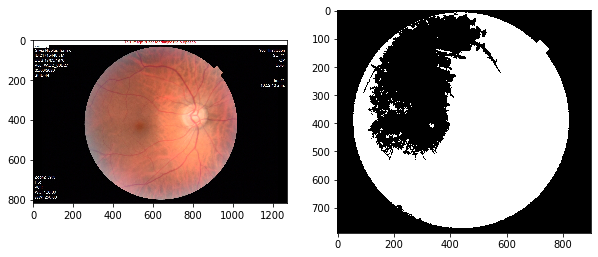

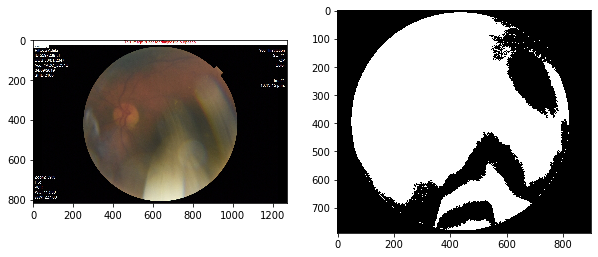

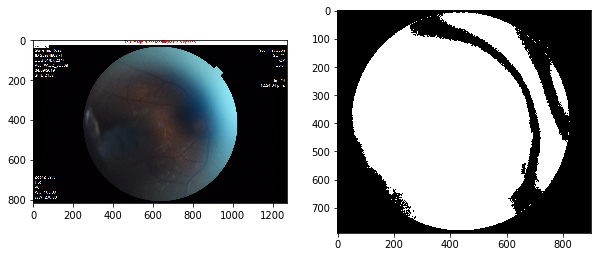

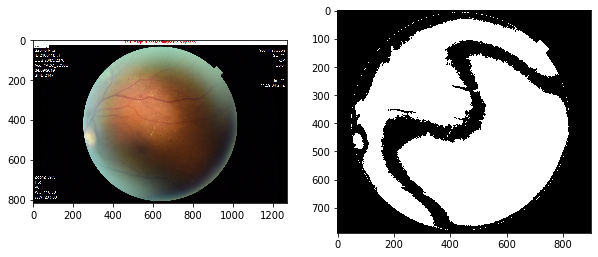

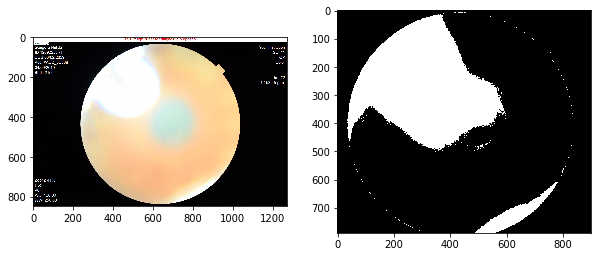

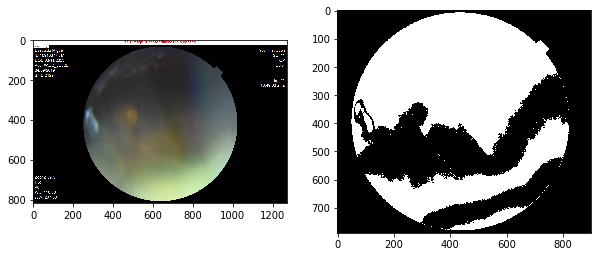

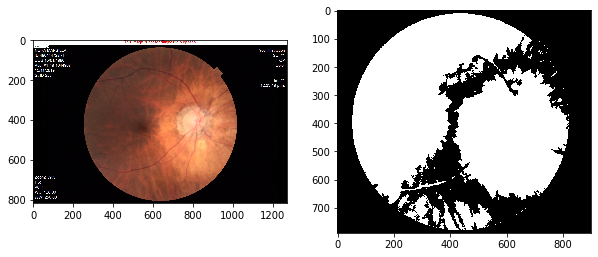

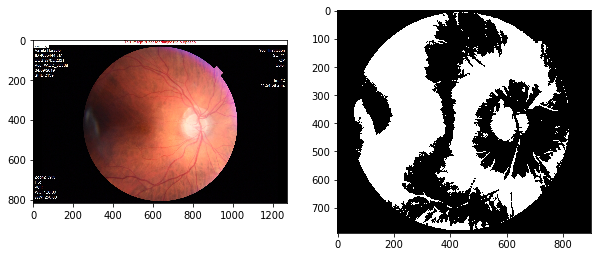

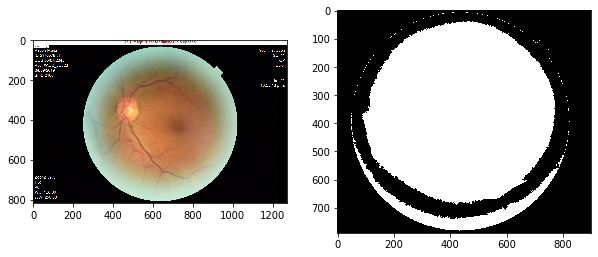

In [165]:
# esta celda se puede borrar es solo para ver como queda el fov
for image_dir in retinografia.file_path:
    im = Image.open(image_dir)
    im_cropped = im.crop((left,top,right,bottom)) # recorta la parte de la imagen con inscripciones.
    im_fov_np = get_fov_mask(im_cropped)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov_np,cmap=plt.cm.gray) 
    plt.show()

### Kaggle

In [55]:
with open(BASE/'labels/Kaggle_zhou.pkl','rb') as f:
    Zhou = pickle.load(f)

In [56]:
with open(BASE/'labels/Kaggle_fu.pkl','rb') as f:
    Fu = pickle.load(f)

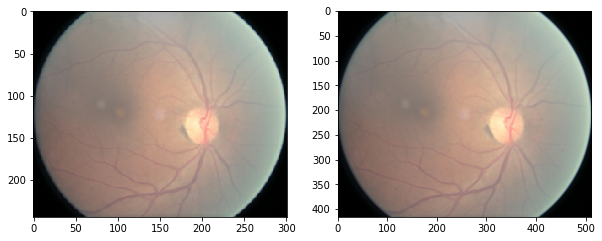

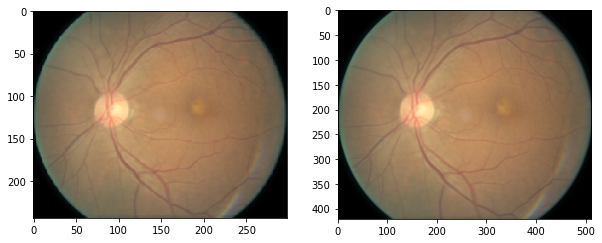

In [57]:
# con PILLOW
for image_dir in set(Zhou.file_path.append(Fu.file_path)):
    new_name = os.path.split(image_dir.with_suffix('.png'))[-1]
    im = Image.open(image_dir)
    im_fov = crop_fov_pill(im)
    im_fov = downsize_image(im_fov)

    im_fov.save(BASE/'images/Kaggle'/new_name)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov,cmap=plt.cm.gray) 
    plt.show()

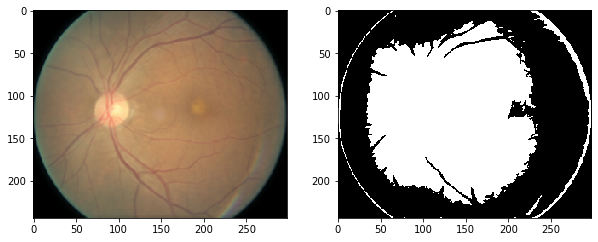

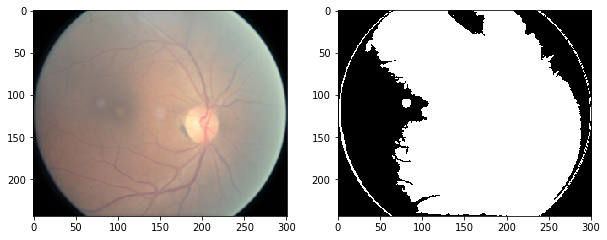

In [125]:
# tb para ver el fov, borrar esta celda despues
for image_dir in set(Zhou.file_path.append(Fu.file_path)):
    im = Image.open(image_dir)
    im_fov_np = get_fov_mask(im)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov_np,cmap=plt.cm.gray) 
    plt.show()

### Deep Diabetic Retinopathy Image Dataset DeepDRiD

In [58]:
with open(BASE/'labels/DRiD.pkl','rb') as f:
    DRID = pickle.load(f)

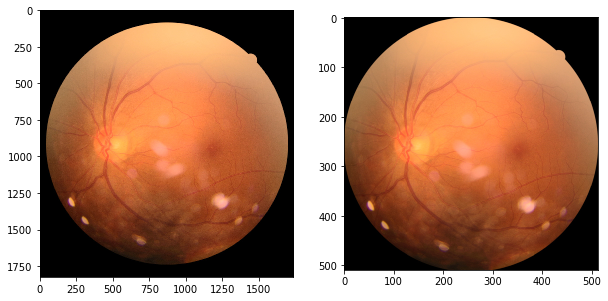

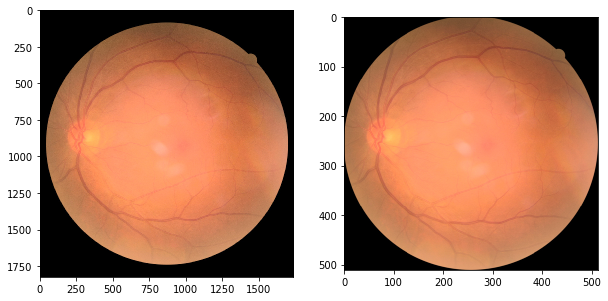

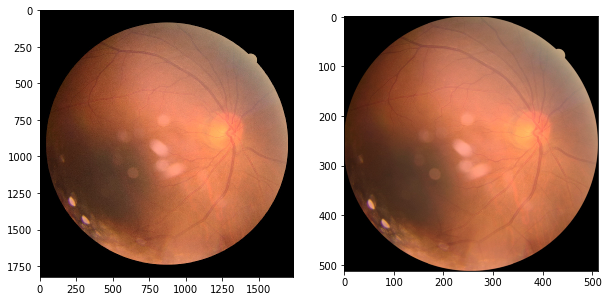

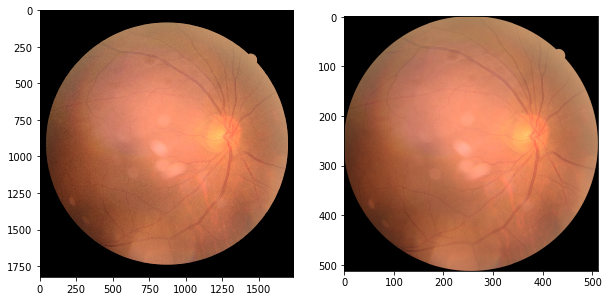

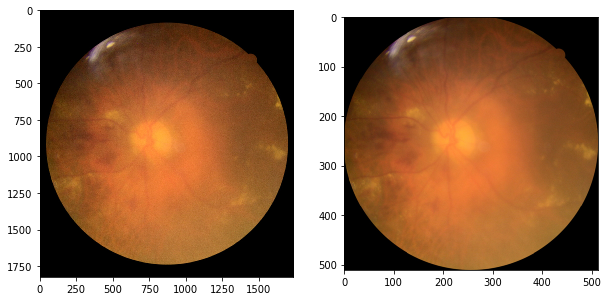

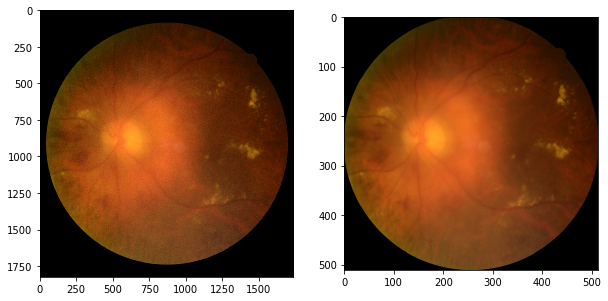

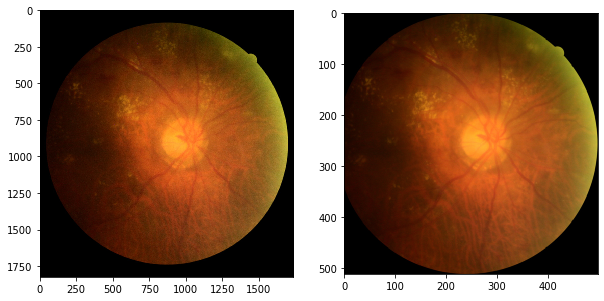

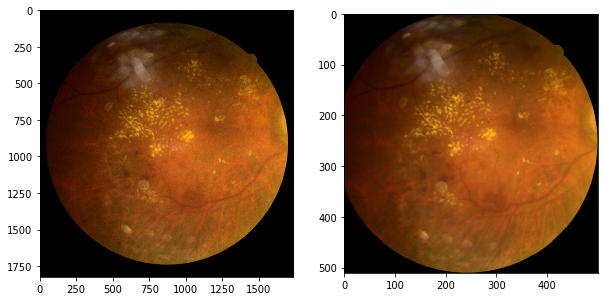

In [59]:
# con PILLOW
for image_dir in DRID.file_path:
    new_name = os.path.split(image_dir.with_suffix('.png'))[-1]
    im = Image.open(image_dir)
    im_fov = crop_fov_pill(im)
    im_fov = downsize_image(im_fov)

    im_fov.save(BASE/'images/Deep-Diabetic-Retinopathy-Image-Dataset-DeepDRiD-'/new_name)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov,cmap=plt.cm.gray) 
    plt.show()

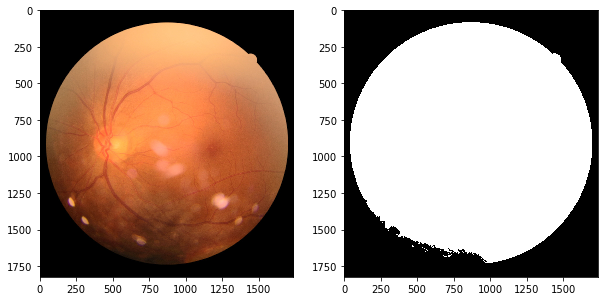

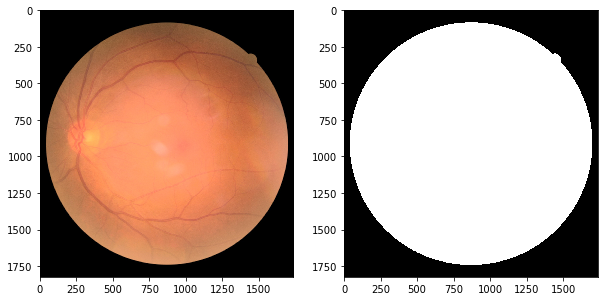

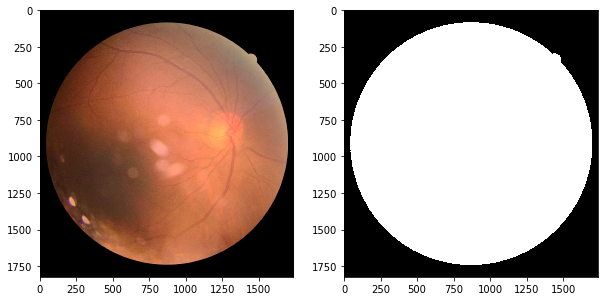

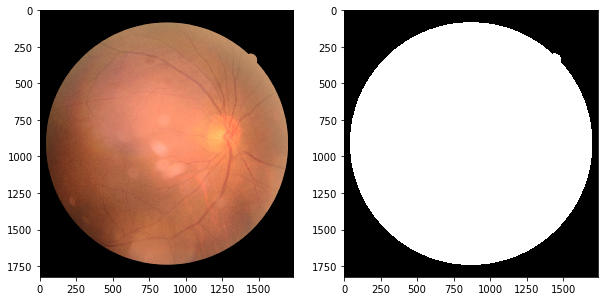

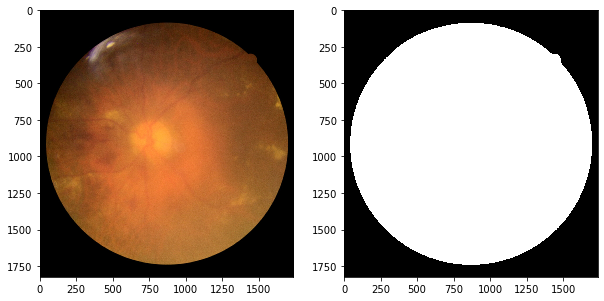

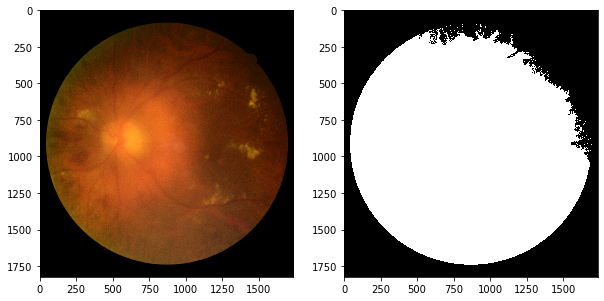

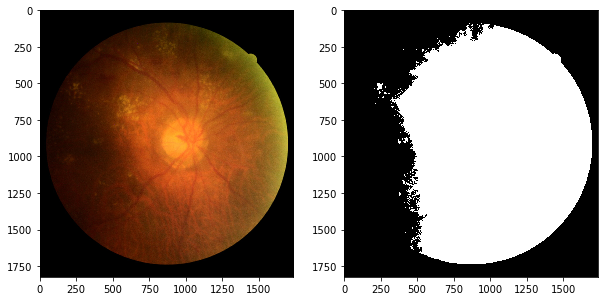

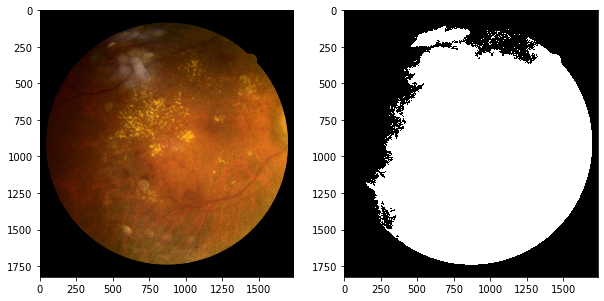

In [18]:
# tb borrar
for image_dir in DRID.file_path:
    im = Image.open(image_dir)
    im_fov_np = get_fov_mask(im)
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))

    ax[0].imshow(im)

    ax[1].imshow(im_fov_np,cmap=plt.cm.gray) 
    plt.show()